### CONEXION DDBB OLIST

In [1]:
%pip install PyMySQL
from sqlalchemy import create_engine, text
import ssl

## CONEXION BBDD MYSQL ##
DB_USER = "nuclio"
DB_PASS = "nuclioTFM6"
DB_HOST = "nuclio.mysql.database.azure.com"
DB_NAME = "olist"

# Crear engine apuntando a la base 'olist'
engine = create_engine(
    f"mysql+pymysql://{DB_USER}:{DB_PASS}@{DB_HOST}:3306/{DB_NAME}?charset=utf8mb4",
    pool_pre_ping=True,
    connect_args={"ssl": {"cert_reqs": ssl.CERT_NONE, "check_hostname": False}} 
)

# tablas 'olist'
with engine.connect() as conn:
    tables = conn.execute(text("SHOW TABLES")).fetchall()
    tables = [row[0] for row in tables]   # convertir a lista simple de strings
    
    print("Tablas en la base 'olist':")
    for t in tables:
        print("-", t)



Note: you may need to restart the kernel to use updated packages.
Tablas en la base 'olist':
- dash_olist_categorias_resumen
- dash_olist_demorados
- dash_olist_sellers
- dash_olist_states
- dash_olist_ventas_meses
- dash_sentiment_analysis
- distribucion_pedidos
- olist_customers_dataset
- olist_geolocation_dataset
- olist_order_items_dataset
- olist_order_payments_dataset
- olist_order_reviews_dataset
- olist_orders_dataset
- olist_products_dataset
- olist_sellers_dataset
- pedidos_por_tiempo
- product_category_name_translation


In [7]:
import pandas as pd
from IPython.display import display, Markdown

# Cargar los datos desde SQL (ventas y pedidos por ciudad)
query = """
SELECT 
    c.customer_city,
    i.price,
    o.order_id,
    o.order_purchase_timestamp
FROM olist_order_items_dataset i
LEFT JOIN olist_orders_dataset o
    ON i.order_id = o.order_id
LEFT JOIN olist_customers_dataset c
    ON o.customer_id = c.customer_id
WHERE o.order_status <> 'canceled'
"""
df = pd.read_sql_query(query, con=engine)

# Convertir fechas y extraer el año de cada pedido
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"], errors="coerce")
df["order_year"] = df["order_purchase_timestamp"].dt.year

# Calcular el total de ventas por año y ciudad
ventas_anuales = (
    df.groupby(["customer_city", "order_year"], dropna=False)
      .agg(total_sales=("price", "sum"))
      .reset_index()
)

# Calcular el número de pedidos únicos por año y ciudad
pedidos_anuales = (
    df.groupby(["customer_city", "order_year"], dropna=False)
      .agg(order_count=("order_id", "nunique"))
      .reset_index()
)

# Crear tablas pivotadas para comparar 2017 y 2018
pivot_sales = (
    ventas_anuales.pivot(index="customer_city", columns="order_year", values="total_sales")
    .fillna(0)
    .reset_index()
)

pivot_orders = (
    pedidos_anuales.pivot(index="customer_city", columns="order_year", values="order_count")
    .fillna(0)
    .astype(int)
    .reset_index()
)

# Renombrar las columnas para que sean más claras
if 2017 in pivot_sales.columns:
    pivot_sales.rename(columns={2017: "TotalSales_2017"}, inplace=True)
if 2018 in pivot_sales.columns:
    pivot_sales.rename(columns={2018: "TotalSales_2018"}, inplace=True)

if 2017 in pivot_orders.columns:
    pivot_orders.rename(columns={2017: "OrderCount_2017"}, inplace=True)
if 2018 in pivot_orders.columns:
    pivot_orders.rename(columns={2018: "OrderCount_2018"}, inplace=True)

# Unir la información de ventas y pedidos en un solo DataFrame
merged_df = pd.merge(pivot_sales, pivot_orders, on="customer_city", how="left")

# Ordenar las ciudades por el total de ventas de 2018
merged_df = merged_df.sort_values(by="TotalSales_2018", ascending=False)

# Mostrar los resultados finales
display(Markdown("#### Ventas y número de pedidos por ciudad (2017–2018)"))
display(
    merged_df[
        [
            "customer_city",
            "TotalSales_2017",
            "TotalSales_2018",
            "OrderCount_2017",
            "OrderCount_2018"
        ]
    ].head(20)
)


#### Ventas y número de pedidos por ciudad (2017–2018)

order_year,customer_city,TotalSales_2017,TotalSales_2018,OrderCount_2017,OrderCount_2018
3587,sao paulo,772480.00,1120751.01,6253,9005
3146,rio de janeiro,490699.42,488958.53,3293,3478
452,belo horizonte,147895.80,201518.88,1183,1543
557,brasilia,132896.95,166262.04,895,1210
1141,curitiba,84071.56,123519.42,638,858
705,campinas,81381.34,105092.93,606,810
3238,salvador,84527.90,96207.82,561,673
2955,porto alegre,91843.17,94129.98,687,677
1526,guarulhos,59160.77,83337.71,482,684
2455,niteroi,48697.86,68489.67,349,492


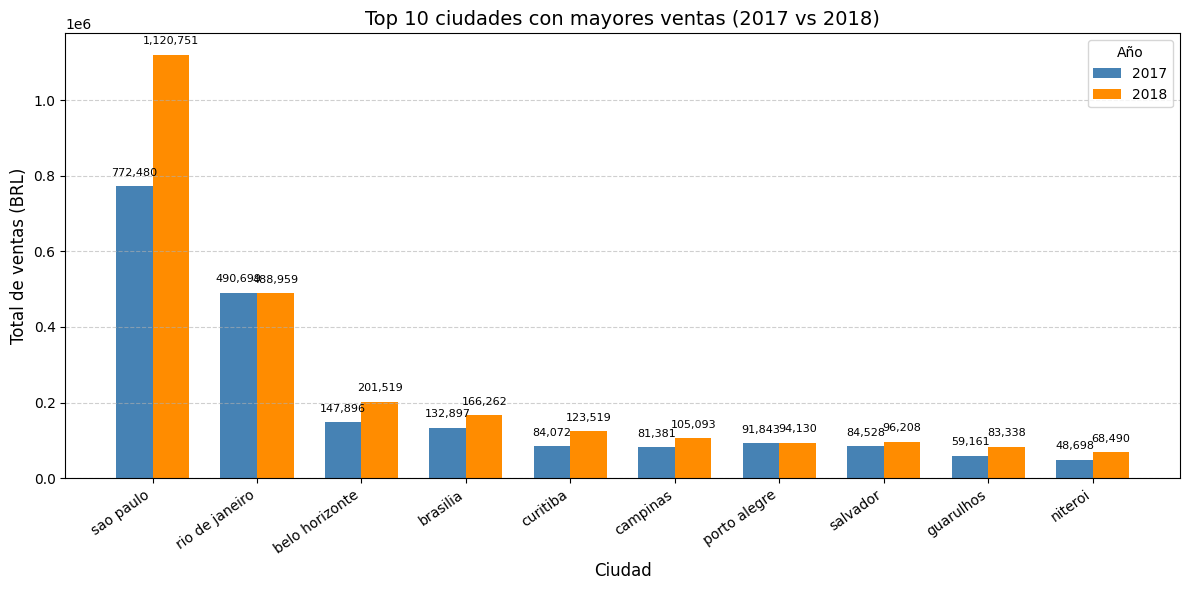

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Seleccionar las 10 ciudades con mayores ventas combinadas (2017 y 2018)
top10_cities = (
    merged_df.assign(Total_2017_2018=lambda x: x["TotalSales_2017"] + x["TotalSales_2018"])
    .sort_values("Total_2017_2018", ascending=False)
    .head(10)
)

# Preparar los datos para el gráfico
cities = top10_cities["customer_city"].tolist()
sales_2017 = top10_cities["TotalSales_2017"].values
sales_2018 = top10_cities["TotalSales_2018"].values

x = np.arange(len(cities))
width = 0.35  # ancho de las barras

# Crear la figura y dibujar las barras
fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, sales_2017, width, label="2017", color="steelblue")
bars2 = ax.bar(x + width/2, sales_2018, width, label="2018", color="darkorange")

# Añadir etiquetas con los valores encima de cada barra
max_height = max(sales_2017.max(), sales_2018.max())
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + (0.02 * max_height),
            f"{height:,.0f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

# Personalizar el gráfico
ax.set_title("Top 10 ciudades con mayores ventas (2017 vs 2018)", fontsize=14)
ax.set_xlabel("Ciudad", fontsize=12)
ax.set_ylabel("Total de ventas (BRL)", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(cities, rotation=35, ha="right")
ax.legend(title="Año")
ax.grid(axis="y", linestyle="--", alpha=0.6)

# Ajustar y mostrar el gráfico
plt.tight_layout()
plt.show()


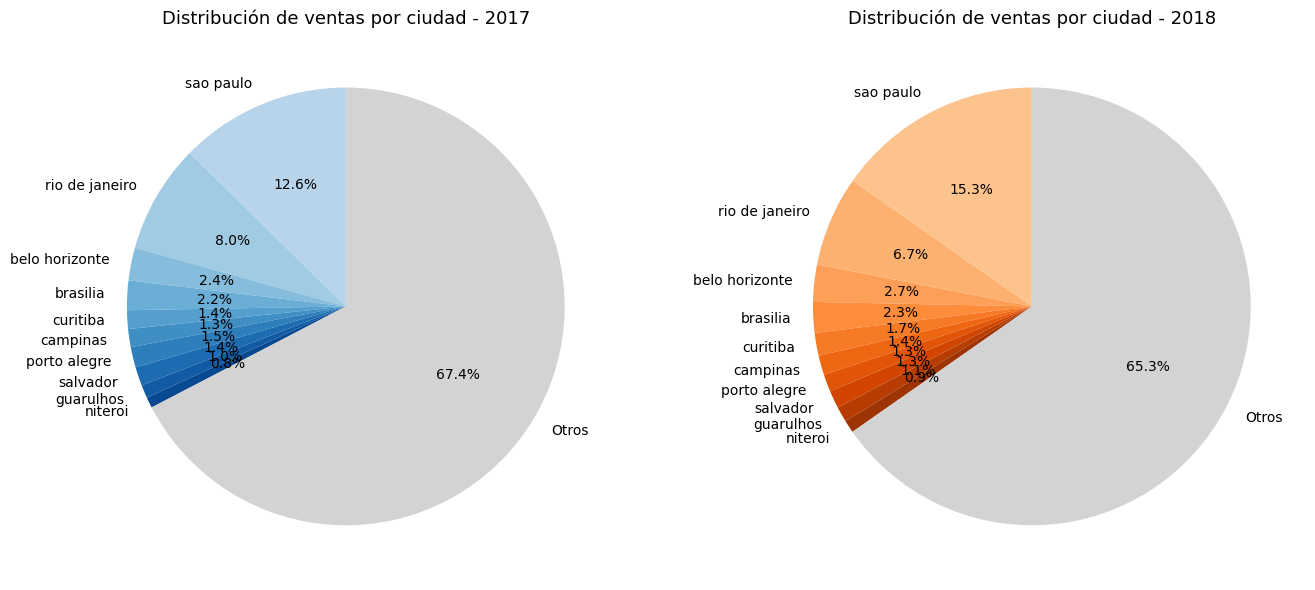

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Calcular el total de ventas combinadas de 2017 y 2018
merged_df["Total_2017_2018"] = merged_df["TotalSales_2017"] + merged_df["TotalSales_2018"]

# Seleccionar las 10 ciudades con más ventas y agrupar el resto como “Otros”
top10_cities = merged_df.sort_values("Total_2017_2018", ascending=False).head(10)
otros = merged_df.iloc[10:].sum(numeric_only=True)

# Crear un nuevo DataFrame con las 10 principales y el grupo “Otros”
top10_plus = pd.concat(
    [top10_cities, pd.DataFrame({
        "customer_city": ["Otros"],
        "TotalSales_2017": [otros["TotalSales_2017"]],
        "TotalSales_2018": [otros["TotalSales_2018"]],
    })],
    ignore_index=True
)

# Preparar los datos para los gráficos
cities = top10_plus["customer_city"].tolist()
sales_2017 = top10_plus["TotalSales_2017"].values
sales_2018 = top10_plus["TotalSales_2018"].values

# Crear una figura con dos gráficos circulares (uno por año)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Definir las paletas de color y asignar gris al grupo “Otros”
colors_2017 = list(plt.cm.Blues(np.linspace(0.3, 0.9, len(cities) - 1))) + ["lightgrey"]
colors_2018 = list(plt.cm.Oranges(np.linspace(0.3, 0.9, len(cities) - 1))) + ["lightgrey"]

# Gráfico circular de 2017
axes[0].pie(
    sales_2017,
    labels=cities,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors_2017
)
axes[0].set_title("Distribución de ventas por ciudad - 2017", fontsize=13)

# Gráfico circular de 2018
axes[1].pie(
    sales_2018,
    labels=cities,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors_2018
)
axes[1].set_title("Distribución de ventas por ciudad - 2018", fontsize=13)

# Ajustar el diseño para evitar solapamientos
plt.tight_layout()
plt.show()


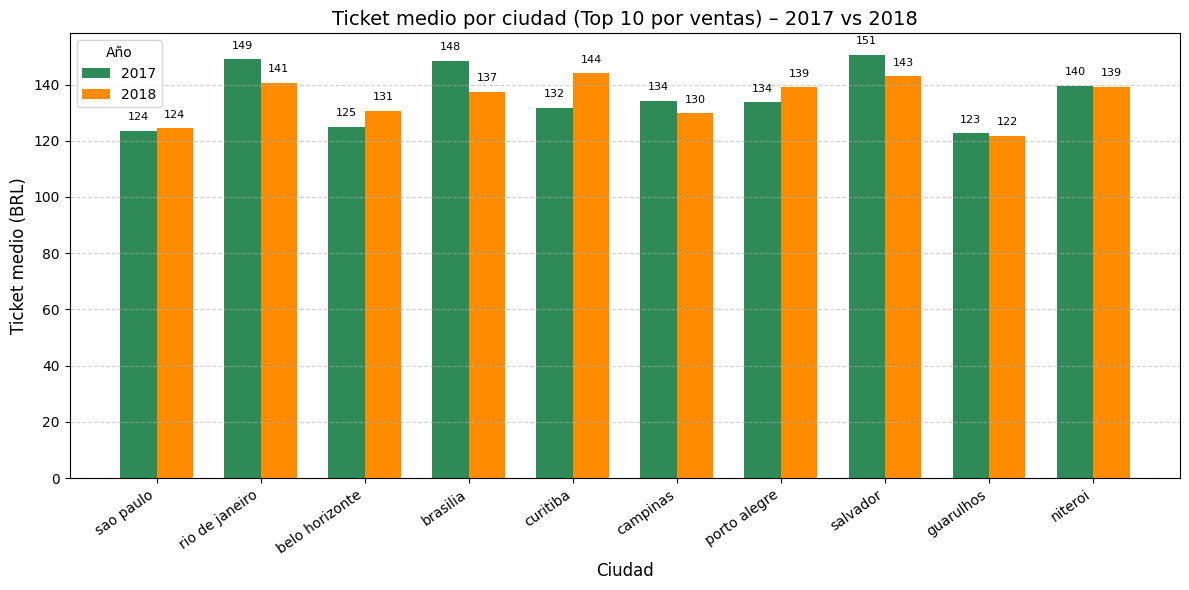

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Calcular el ticket medio por ciudad y año (total ventas / número de pedidos)
merged_df["AvgTicket_2017"] = (
    merged_df["TotalSales_2017"] / merged_df["OrderCount_2017"].replace(0, np.nan)
).round(2)

merged_df["AvgTicket_2018"] = (
    merged_df["TotalSales_2018"] / merged_df["OrderCount_2018"].replace(0, np.nan)
).round(2)

# Seleccionar las 10 ciudades con mayores ventas combinadas entre 2017 y 2018
top10_cities = (
    merged_df.assign(Total_2017_2018=lambda x: x["TotalSales_2017"] + x["TotalSales_2018"])
    .sort_values("Total_2017_2018", ascending=False)
    .head(10)
)

# Preparar los datos para el gráfico
cities = top10_cities["customer_city"].tolist()
avg_ticket_2017 = top10_cities["AvgTicket_2017"].values
avg_ticket_2018 = top10_cities["AvgTicket_2018"].values

x = np.arange(len(cities))
width = 0.35  # ancho de las barras

# Crear la figura y las barras para cada año
fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, avg_ticket_2017, width, label="2017", color="seagreen")
bars2 = ax.bar(x + width/2, avg_ticket_2018, width, label="2018", color="darkorange")

# Añadir etiquetas de valor sobre cada barra
max_height = max(np.nanmax(avg_ticket_2017), np.nanmax(avg_ticket_2018))
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if not np.isnan(height):
            ax.text(
                bar.get_x() + bar.get_width()/2,
                height + (0.02 * max_height),
                f"{height:,.0f}",
                ha="center",
                va="bottom",
                fontsize=8
            )

# Personalizar el gráfico
ax.set_title("Ticket medio por ciudad (Top 10 por ventas) – 2017 vs 2018", fontsize=14)
ax.set_xlabel("Ciudad", fontsize=12)
ax.set_ylabel("Ticket medio (BRL)", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(cities, rotation=35, ha="right")
ax.legend(title="Año")
ax.grid(axis="y", linestyle="--", alpha=0.6)

# Ajustar el diseño y mostrar el gráfico
plt.tight_layout()
plt.show()


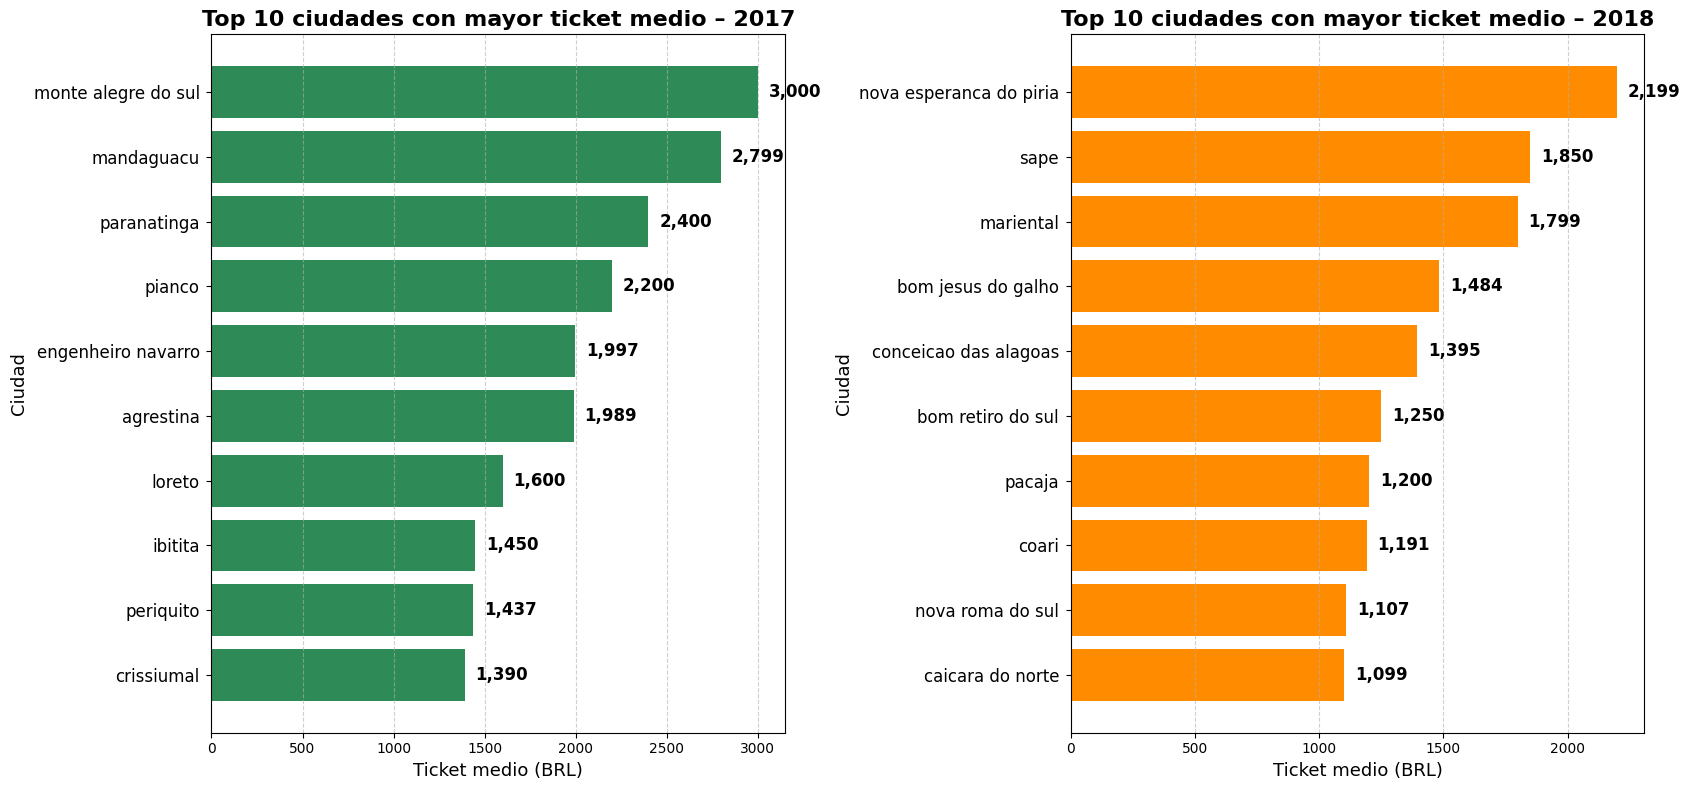

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Calcular el ticket medio por ciudad y año (total ventas / pedidos)
merged_df["AvgTicket_2017"] = (
    merged_df["TotalSales_2017"] / merged_df["OrderCount_2017"].replace(0, np.nan)
).round(2)

merged_df["AvgTicket_2018"] = (
    merged_df["TotalSales_2018"] / merged_df["OrderCount_2018"].replace(0, np.nan)
).round(2)

# Seleccionar las 10 ciudades con mayor ticket medio en cada año
top10_2017 = merged_df.sort_values("AvgTicket_2017", ascending=False).head(10)
top10_2018 = merged_df.sort_values("AvgTicket_2018", ascending=False).head(10)

# Crear una figura con dos gráficos horizontales (uno por año)
fig, axes = plt.subplots(1, 2, figsize=(17, 8))

# Gráfico para 2017
bars1 = axes[0].barh(top10_2017["customer_city"], top10_2017["AvgTicket_2017"], color="seagreen")
axes[0].set_title("Top 10 ciudades con mayor ticket medio – 2017", fontsize=16, fontweight="bold")
axes[0].set_xlabel("Ticket medio (BRL)", fontsize=13)
axes[0].set_ylabel("Ciudad", fontsize=13)
axes[0].invert_yaxis()
axes[0].grid(axis="x", linestyle="--", alpha=0.6)
axes[0].tick_params(axis="y", labelsize=12, pad=5)

# Añadir etiquetas con los valores en cada barra
max_width_2017 = np.nanmax(top10_2017["AvgTicket_2017"])
for bar in bars1:
    width = bar.get_width()
    axes[0].text(
        width + (0.02 * max_width_2017),
        bar.get_y() + bar.get_height() / 2,
        f"{width:,.0f}",
        va="center",
        fontsize=12,
        fontweight="bold"
    )

# Gráfico para 2018
bars2 = axes[1].barh(top10_2018["customer_city"], top10_2018["AvgTicket_2018"], color="darkorange")
axes[1].set_title("Top 10 ciudades con mayor ticket medio – 2018", fontsize=16, fontweight="bold")
axes[1].set_xlabel("Ticket medio (BRL)", fontsize=13)
axes[1].set_ylabel("Ciudad", fontsize=13)
axes[1].invert_yaxis()
axes[1].grid(axis="x", linestyle="--", alpha=0.6)
axes[1].tick_params(axis="y", labelsize=12, pad=5)

# Añadir etiquetas con los valores en cada barra
max_width_2018 = np.nanmax(top10_2018["AvgTicket_2018"])
for bar in bars2:
    width = bar.get_width()
    axes[1].text(
        width + (0.02 * max_width_2018),
        bar.get_y() + bar.get_height() / 2,
        f"{width:,.0f}",
        va="center",
        fontsize=12,
        fontweight="bold"
    )

# Ajustar el diseño y mostrar la figura
plt.tight_layout()
plt.show()
